In [22]:
# setup data
from sklearn import datasets

N_SAMPLE = 1000

X , y = datasets.make_blobs(n_samples=N_SAMPLE , centers=4, random_state=42) # 3 class

In [23]:
X, y

(array([[-8.55503989,  7.06461794],
        [-6.13753182, -6.58081701],
        [-6.32130028, -6.8041042 ],
        ...,
        [ 3.69047995,  4.60555175],
        [-7.48913939, -7.0670809 ],
        [-9.40049578,  7.11430104]]),
 array([3, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 3, 0, 2, 2, 2, 0, 0, 0, 1, 1, 3,
        3, 3, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 3, 2, 1, 3, 3, 1, 2, 1, 3,
        1, 3, 0, 1, 3, 1, 2, 0, 1, 3, 0, 3, 0, 0, 0, 2, 2, 0, 2, 3, 1, 0,
        2, 2, 1, 0, 3, 0, 1, 2, 1, 3, 1, 0, 1, 0, 2, 0, 0, 0, 1, 3, 2, 2,
        0, 0, 0, 0, 1, 1, 3, 1, 3, 0, 1, 2, 1, 3, 3, 0, 3, 1, 1, 0, 2, 0,
        3, 2, 1, 1, 1, 1, 2, 3, 2, 1, 0, 2, 3, 1, 3, 2, 1, 3, 2, 1, 0, 2,
        1, 3, 1, 3, 0, 2, 1, 1, 0, 0, 3, 3, 3, 1, 1, 0, 0, 0, 0, 3, 2, 2,
        0, 1, 0, 1, 1, 3, 2, 0, 1, 2, 0, 0, 1, 2, 3, 2, 1, 0, 0, 1, 0, 3,
        2, 3, 2, 3, 1, 1, 0, 2, 0, 2, 1, 3, 0, 2, 1, 0, 1, 1, 0, 3, 2, 2,
        2, 3, 0, 2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 3, 2, 2, 1, 0, 2, 0, 3, 1,
        3, 3, 2, 0, 3, 0, 1, 

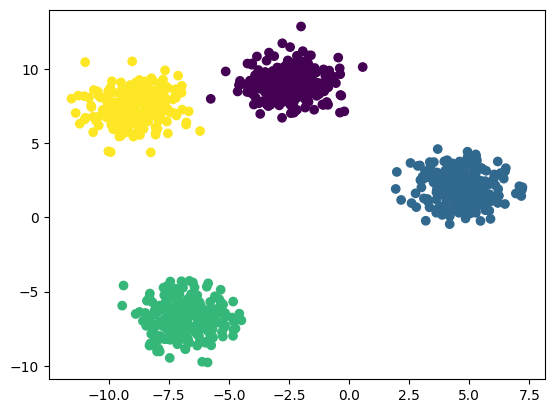

In [24]:
# visaulize
import matplotlib.pyplot as plt

plt.scatter(X[:, 0],X[:,1], c=y)

In [25]:
type(X) , type(y)

(numpy.ndarray, numpy.ndarray)

In [27]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.long)


TypeError: expected np.ndarray (got Tensor)

In [29]:
X.dtype , y.dtype

(torch.float32, torch.int64)

In [30]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(X,y, train_size=0.8, random_state=42)


In [31]:
len(X_test)

200

In [53]:
from  torch import nn
class Claasificationv3(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = torch.nn.Sequential(
            nn.Linear(in_features=2, out_features=8),
            nn.Linear(in_features=8, out_features=8),
            nn.Linear(in_features=8, out_features=4)
        )
        
    def forward(self, x):
        return self.layers(x)

In [54]:
model_1 = Claasificationv3()

model_1

Claasificationv3(
  (layers): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [55]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)


In [56]:
# training loop
from helpers import accuracy_fn
EPOCHS = 100
for epoch in range(EPOCHS):
    model_1.train()
    
    train_logits = model_1(X_train)
    preds_prob = torch.softmax(train_logits, dim=1)
    pred_label = preds_prob.argmax(dim=1)
    
    train_loss = loss_fn(train_logits, y_train)
    train_acc = accuracy_fn(y_train, pred_label)
    optimizer.zero_grad()
    
    train_loss.backward()
    optimizer.step()
    
    model_1.eval()
    with torch.no_grad():
        test_logits = model_1(X_test)
        test_label = torch.softmax(test_logits, dim=1).argmax(dim=1)
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_test, test_label)

        
        if epoch%10 == 0:
            print(f"Epoch : {epoch} | train loss = {train_loss} | test_loss : {test_loss} | train acc : {train_acc} | test acc : {test_acc}")

Epoch : 0 | train loss = 0.7336046099662781 | test_loss : 0.5001481175422668 | train acc : 67.375 | test acc : 75.0
Epoch : 10 | train loss = 0.1079116091132164 | test_loss : 0.09751731157302856 | train acc : 99.875 | test acc : 100.0
Epoch : 20 | train loss = 0.048988018184900284 | test_loss : 0.04524071514606476 | train acc : 99.875 | test acc : 100.0
Epoch : 30 | train loss = 0.030675416812300682 | test_loss : 0.027996951714158058 | train acc : 99.875 | test acc : 100.0
Epoch : 40 | train loss = 0.022202296182513237 | test_loss : 0.019880160689353943 | train acc : 99.875 | test acc : 100.0
Epoch : 50 | train loss = 0.017419086769223213 | test_loss : 0.0152735635638237 | train acc : 99.875 | test acc : 100.0
Epoch : 60 | train loss = 0.014378853142261505 | test_loss : 0.012344245798885822 | train acc : 99.875 | test acc : 100.0
Epoch : 70 | train loss = 0.012288665398955345 | test_loss : 0.01033398974686861 | train acc : 99.875 | test acc : 100.0
Epoch : 80 | train loss = 0.010769349

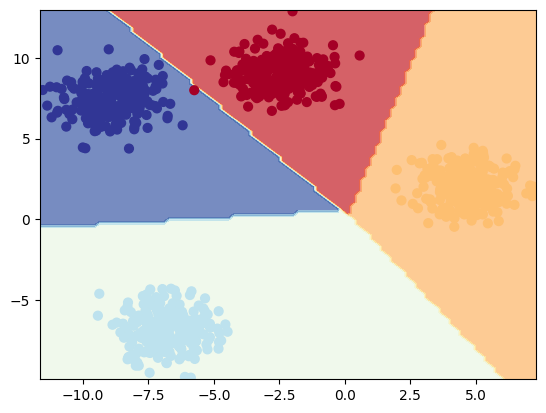

In [60]:
from helpers import plot_decision_boundary

plot_decision_boundary(model=model_1, X=X,y=y)